Loading sample 354 from /root/nyu_depth_v2_labeled.mat...


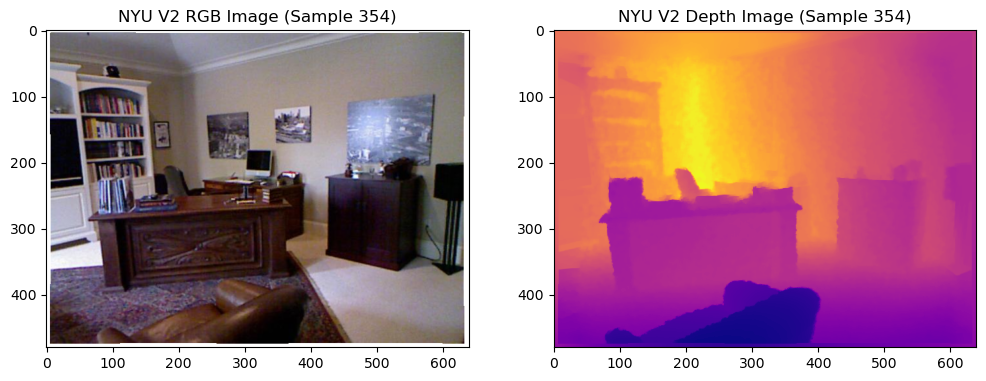

Generated 307200 points. Visualizing 61440 points.


In [14]:
import torch
import torch.nn.functional as F
import numpy as np
import einops
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import h5py # You'll need to install this: pip install h5py
import random
class PointCloudUtils:
    """
    Your existing PointCloudUtils class. No changes needed here.
    """
    @staticmethod
    def depth2fgpcd_batch(depth, cam_params):
        B, ncam, h, w = depth.shape
        fx = cam_params[..., 0, 0].view(B, ncam, 1, 1)
        fy = cam_params[..., 1, 1].view(B, ncam, 1, 1)
        cx = cam_params[..., 0, 2].view(B, ncam, 1, 1)
        cy = cam_params[..., 1, 2].view(B, ncam, 1, 1)
        pos_y, pos_x = torch.meshgrid(torch.arange(h, device=depth.device, dtype=torch.float32), torch.arange(w, device=depth.device, dtype=torch.float32), indexing='ij')
        pos_x = pos_x.expand(B, ncam, -1, -1)
        pos_y = pos_y.expand(B, ncam, -1, -1)
        x_coords = (pos_x - cx) * depth / fx
        y_coords = (pos_y - cy) * depth / fy
        pcd_cam = torch.stack([x_coords, y_coords, depth], dim=-1)
        return einops.rearrange(pcd_cam, 'b ncam h w c -> b ncam (h w) c')

    @staticmethod
    def batch_transform_point_cloud(pcd, transform):
        pcd_homo = F.pad(pcd, (0, 1), mode='constant', value=1.0)
        transform = transform.to(dtype=pcd.dtype)
        trans_pcd_homo = torch.einsum('bn...d,bn...id->bn...i', pcd_homo, transform)
        return trans_pcd_homo[..., :-1]

    @staticmethod
    def lift_point_cloud_batch(depths, intrinsics, extrinsics):
        pcd_cam = PointCloudUtils.depth2fgpcd_batch(depths, intrinsics)
        trans_pcd = PointCloudUtils.batch_transform_point_cloud(pcd_cam, extrinsics)
        return trans_pcd

def load_nyu_v2_data(filepath, index=0):
    """
    Loads a single RGB-D sample and camera intrinsics from the .mat file.
    
    Args:
        filepath (str): Path to the nyu_depth_v2_labeled.mat file.
        index (int): The index of the sample to load (0 to 1448).

    Returns:
        A tuple containing: (depth_tensor, intrinsics_tensor, extrinsics_tensor, rgb_image, depth_image)
    """
    print(f"Loading sample {index} from {filepath}...")
    with h5py.File(filepath, 'r') as f:
        # The data is stored with different axis orders, so we need to transpose.
        # Images are (3, W, H), we want (H, W, 3) for visualization.
        rgb_image = np.transpose(f['images'][index], axes=[2, 1, 0])
        # Depths are (W, H), we want (H, W).
        depth_image = np.transpose(f['depths'][index], axes=[1, 0])

    H, W, _ = rgb_image.shape
    
    # Convert to PyTorch tensors and add batch/ncam dimensions (B, NCAM, H, W)
    depth_tensor = torch.from_numpy(depth_image).float().view(1, 1, H, W)

    # Standard camera intrinsics for NYU Depth V2
    intrinsics_numpy = np.array([
        [582.62, 0,      313.04],
        [0,      582.69, 239.89],
        [0,      0,      1]
    ], dtype=np.float32)
    
    intrinsics_tensor = torch.from_numpy(intrinsics_numpy).view(1, 1, 3, 3)
    
    # Assume identity extrinsics, as the depth is already in the camera frame
    extrinsics_tensor = torch.eye(4).view(1, 1, 4, 4)
    
    return depth_tensor, intrinsics_tensor, extrinsics_tensor, rgb_image, depth_image

def main():
    """
    Main function to load NYU V2 data, lift it to a point cloud, and visualize.
    """
    # 1. DEFINE FILE PATH
    # IMPORTANT: Replace this with the actual path to your .mat file
    FILE_PATH = '/root/nyu_depth_v2_labeled.mat'
    SAMPLE_INDEX = random.randint(0, 1448) # Choose a sample to visualize (0-1448)

    try:
        # 2. Load Real Data
        depth_tensor, intrinsics, extrinsics, rgb_img, depth_img = load_nyu_v2_data(FILE_PATH, index=SAMPLE_INDEX)
    except FileNotFoundError:
        print(f"ERROR: File not found at '{FILE_PATH}'.")
        print("Please update the FILE_PATH variable with the correct location of your .mat file.")
        return

    # 3. Visualize Input Images
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.imshow(rgb_img)
    ax1.set_title(f'NYU V2 RGB Image (Sample {SAMPLE_INDEX})')
    ax2.imshow(depth_img, cmap='plasma')
    ax2.set_title(f'NYU V2 Depth Image (Sample {SAMPLE_INDEX})')
    plt.show()

    # 4. Generate Point Cloud
    pcd = PointCloudUtils.lift_point_cloud_batch(depth_tensor, intrinsics, extrinsics).squeeze().numpy()

    # 5. Prepare Colors for Visualization
    # Reshape the RGB image to a list of colors for each point
    colors = rgb_img.reshape(-1, 3)

    # Optional: Subsample points for faster visualization
    num_points = pcd.shape[0]
    subsample_factor = 5
    pcd_sub = pcd[::subsample_factor]
    colors_sub = colors[::subsample_factor]
    
    print(f"Generated {num_points} points. Visualizing {pcd_sub.shape[0]} points.")

    # 6. Interactive 3D Visualization with Plotly
    fig = go.Figure(data=[go.Scatter3d(
        x=pcd_sub[:, 0],
        y=pcd_sub[:, 1],
        z=pcd_sub[:, 2],
        mode='markers',
        marker=dict(
            size=1,
            color=colors_sub,  # Use RGB colors
            opacity=0.8
        )
    )])

    fig.update_layout(
        title_text=f'3D Point Cloud from NYU Depth V2 (Sample {SAMPLE_INDEX})',
        height=800,
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectratio=dict(x=1, y=1, z=1),
            # Invert Z-axis for a more natural camera view
            camera_eye=dict(x=0, y=0, z=-2.5) 
        )
    )
    
    fig.show()


if __name__ == '__main__':
    main()